# Лекция 4. Метод опорных векторов — демонстрации

Геометрия зазора, опорные векторы, мягкий зазор и роль $C$, ядерный трюк.

> Ноутбук сопровождает лекцию: каждый раздел иллюстрирует кодом соответствующий
> теоретический сюжет. Запускайте ячейки по порядку.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (7, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## 1. Зазор и опорные векторы

SVM ищет гиперплоскость с **максимальным зазором**:

$$\min_w \frac{1}{2}\|w\|^2 \quad \text{при} \quad y_i(w^T x_i + b) \ge 1.$$

Ширина зазора равна $2/\|w\|$. Решение определяется только объектами на границе —
опорными векторами; остальные точки можно удалить, и разделяющая поверхность не изменится.

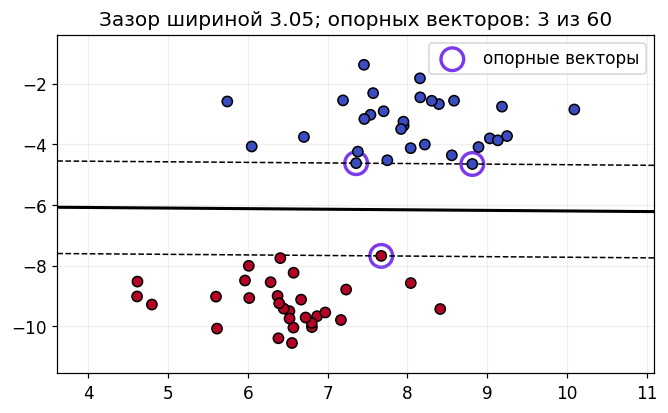

In [2]:
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

X, y = make_blobs(n_samples=60, centers=2, cluster_std=0.85, random_state=6)
clf = SVC(kernel="linear", C=1000).fit(X, y)     # большое C ≈ жёсткий зазор

xx = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300)
yy = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
XX, YY = np.meshgrid(xx, yy)
Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=45, edgecolor="k", zorder=3)
plt.contour(XX, YY, Z, levels=[-1, 0, 1], colors="k",
            linestyles=["--", "-", "--"], linewidths=[1, 2, 1])
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=220, facecolors="none", edgecolors="#7c3aed", linewidths=2.2, label="опорные векторы")
plt.title(f"Зазор шириной {2 / np.linalg.norm(clf.coef_):.2f}; "
          f"опорных векторов: {len(clf.support_vectors_)} из {len(X)}")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 2. Мягкий зазор: роль параметра $C$

$$\min_{w, \xi} \frac{1}{2}\|w\|^2 + C\sum_i \xi_i, \qquad y_i(w^T x_i + b) \ge 1 - \xi_i,\ \xi_i \ge 0.$$

Большое $C$ — почти не прощаем ошибок, зазор узкий, риск переобучения.
Малое $C$ — широкий зазор, часть объектов внутри него, модель проще.

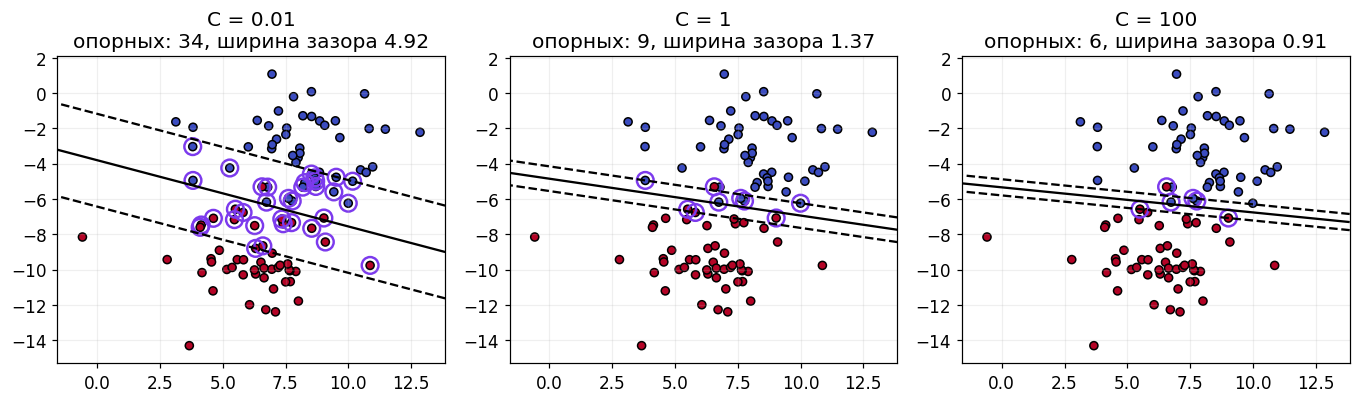

In [3]:
X_ovl, y_ovl = make_blobs(n_samples=100, centers=2, cluster_std=1.9, random_state=6)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
for ax, C in zip(axes, [0.01, 1, 100]):
    model = SVC(kernel="linear", C=C).fit(X_ovl, y_ovl)
    xx = np.linspace(X_ovl[:, 0].min() - 1, X_ovl[:, 0].max() + 1, 200)
    yy = np.linspace(X_ovl[:, 1].min() - 1, X_ovl[:, 1].max() + 1, 200)
    XX, YY = np.meshgrid(xx, yy)
    Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)

    ax.scatter(X_ovl[:, 0], X_ovl[:, 1], c=y_ovl, cmap="coolwarm", s=28, edgecolor="k")
    ax.contour(XX, YY, Z, levels=[-1, 0, 1], colors="k", linestyles=["--", "-", "--"])
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=120, facecolors="none", edgecolors="#7c3aed", linewidths=1.6)
    ax.set_title(f"C = {C}\nопорных: {len(model.support_vectors_)}, "
                 f"ширина зазора {2 / np.linalg.norm(model.coef_):.2f}")
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 3. Ядерный трюк

Вместо явного отображения $\varphi(x)$ в спрямляющее пространство считаем только скалярные
произведения $K(x, z) = \langle \varphi(x), \varphi(z)\rangle$.

Классический пример: концентрические окружности неразделимы прямой в $\mathbb{R}^2$,
но становятся разделимы плоскостью после добавления третьей координаты $z = x_1^2 + x_2^2$.

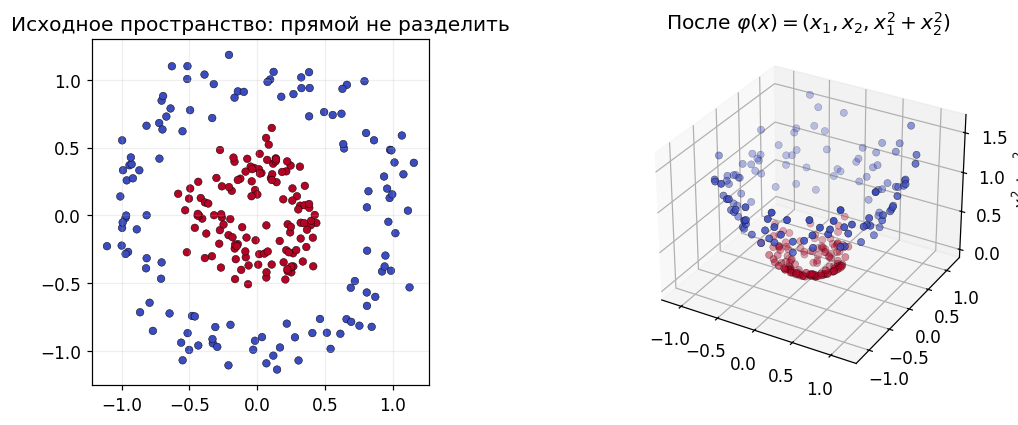

In [4]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.datasets import make_circles

Xc, yc = make_circles(n_samples=250, factor=0.35, noise=0.1, random_state=RANDOM_STATE)
z = Xc[:, 0] ** 2 + Xc[:, 1] ** 2

fig = plt.figure(figsize=(11, 4))
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", s=25, edgecolor="k", linewidth=0.3)
ax1.set_title("Исходное пространство: прямой не разделить")
ax1.set_aspect("equal"); ax1.grid(alpha=0.2)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(Xc[:, 0], Xc[:, 1], z, c=yc, cmap="coolwarm", s=22, edgecolor="k", linewidth=0.3)
ax2.set_title(r"После $\varphi(x) = (x_1, x_2, x_1^2 + x_2^2)$")
ax2.set_zlabel("$x_1^2 + x_2^2$")
plt.tight_layout()
plt.show()

## 4. Популярные ядра в деле

$$K_{\text{lin}} = \langle x, z\rangle, \quad
  K_{\text{poly}} = (\gamma\langle x, z\rangle + r)^d, \quad
  K_{\text{RBF}} = e^{-\gamma\|x - z\|^2}.$$

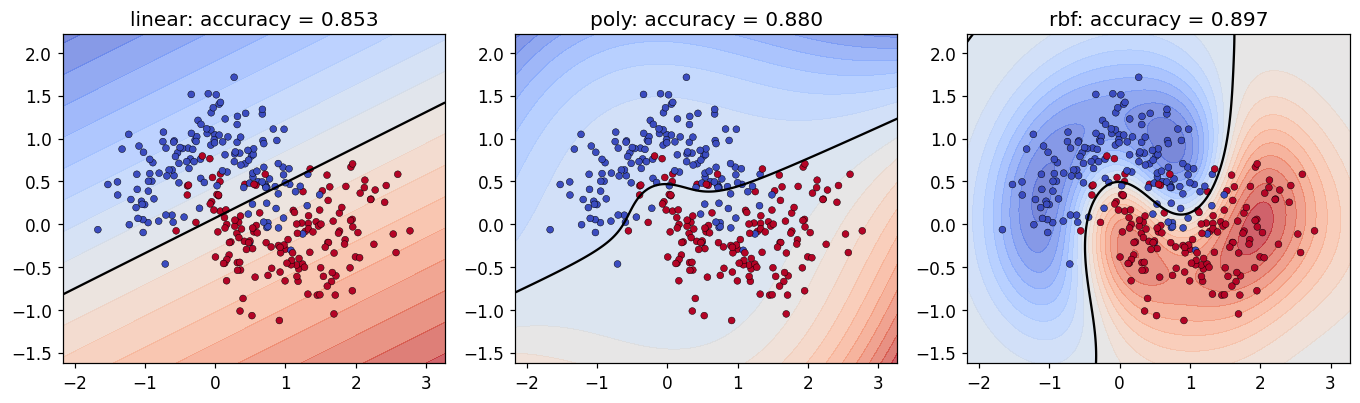

In [5]:
from sklearn.datasets import make_moons

Xm, ym = make_moons(n_samples=300, noise=0.28, random_state=RANDOM_STATE)
kernels = [("linear", {}), ("poly", {"degree": 3}), ("rbf", {"gamma": 1.0})]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
for ax, (kernel, params) in zip(axes, kernels):
    model = SVC(kernel=kernel, C=1.0, **params).fit(Xm, ym)
    xx, yy = np.meshgrid(np.linspace(Xm[:, 0].min() - .5, Xm[:, 0].max() + .5, 250),
                         np.linspace(Xm[:, 1].min() - .5, Xm[:, 1].max() + .5, 250))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.7)
    ax.contour(xx, yy, Z, levels=[0], colors="k", linewidths=1.5)
    ax.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="coolwarm", s=20, edgecolor="k", linewidth=0.3)
    ax.set_title(f"{kernel}: accuracy = {model.score(Xm, ym):.3f}")
    ax.grid(False)
plt.tight_layout()
plt.show()

## 5. Переобучение по $\gamma$

Большое $\gamma$ делает радиус влияния объекта крошечным: модель окружает каждую точку
собственным «островом» и запоминает выборку.

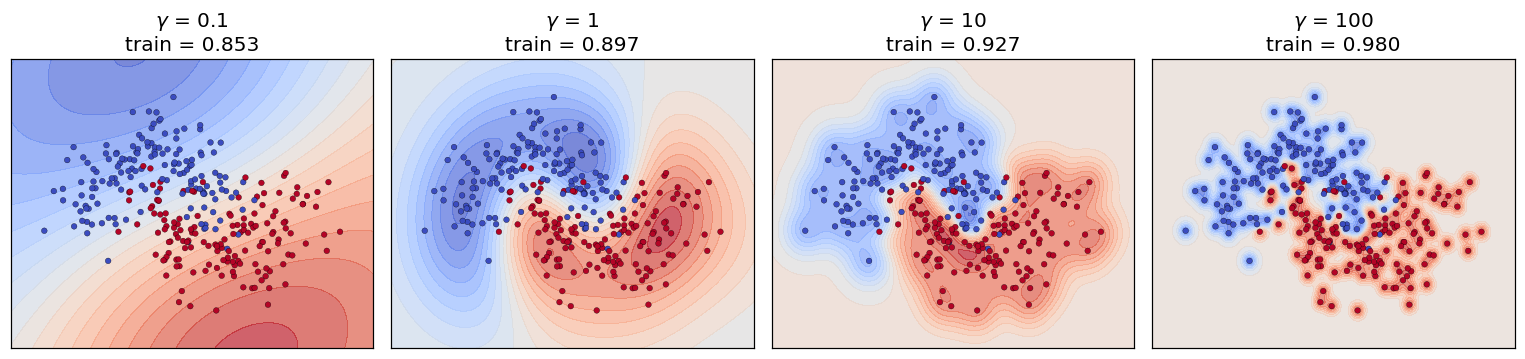

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, gamma in zip(axes, [0.1, 1, 10, 100]):
    model = SVC(kernel="rbf", C=1.0, gamma=gamma).fit(Xm, ym)
    xx, yy = np.meshgrid(np.linspace(Xm[:, 0].min() - .5, Xm[:, 0].max() + .5, 220),
                         np.linspace(Xm[:, 1].min() - .5, Xm[:, 1].max() + .5, 220))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.7)
    ax.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="coolwarm", s=14, edgecolor="k", linewidth=0.2)
    ax.set_title(f"$\\gamma$ = {gamma}\ntrain = {model.score(Xm, ym):.3f}")
    ax.grid(False); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()